In [ ]:
!pip -q install kagglehub torch torchvision pytorch-lightning torchmetrics scikit-learn matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.6/831.6 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 14.3 MB/s eta 0:00:00


In [ ]:
import os, math, itertools
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor

from torchmetrics.classification import (
    MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score, MulticlassConfusionMatrix
)

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

pl.seed_everything(42, workers=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
device


INFO:lightning_fabric.utilities.seed:Seed set to 42


'cuda'

In [ ]:
import kagglehub, os
base_path = kagglehub.dataset_download("yudhaislamisulistya/plants-type-datasets")
print("Base path:", base_path)
print(os.listdir(base_path))

DATA_ROOT = Path(base_path) / "split_ttv_dataset_type_of_plants"
TRAIN_DIR = DATA_ROOT / "Train_Set_Folder"
VAL_DIR   = DATA_ROOT / "Validation_Set_Folder"
TEST_DIR  = DATA_ROOT / "Test_Set_Folder"

print("Train:", TRAIN_DIR.exists(), "Val:", VAL_DIR.exists(), "Test:", TEST_DIR.exists())


Using Colab cache for faster access to the 'plants-type-datasets' dataset.
Base path: /kaggle/input/plants-type-datasets
['split_ttv_dataset_type_of_plants']
Train: True Val: True Test: True


In [ ]:
IMG_SIZE = 192
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])


In [ ]:
train_ds = datasets.ImageFolder(TRAIN_DIR.as_posix(), transform=train_tf)
val_ds   = datasets.ImageFolder(VAL_DIR.as_posix(),   transform=eval_tf)
test_ds  = datasets.ImageFolder(TEST_DIR.as_posix(),  transform=eval_tf)

num_classes = len(train_ds.classes)
class_names = train_ds.classes
print(f"Classes ({num_classes}):", class_names[:10], "..." if num_classes>10 else "")
print("Num images — Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))

BATCH_SIZE = 128
NUM_WORKERS = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
len(train_loader), len(val_loader), len(test_loader)


Classes (30): ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant'] ...
Num images — Train: 23972 Val: 3030 Test: 2998


(188, 24, 24)

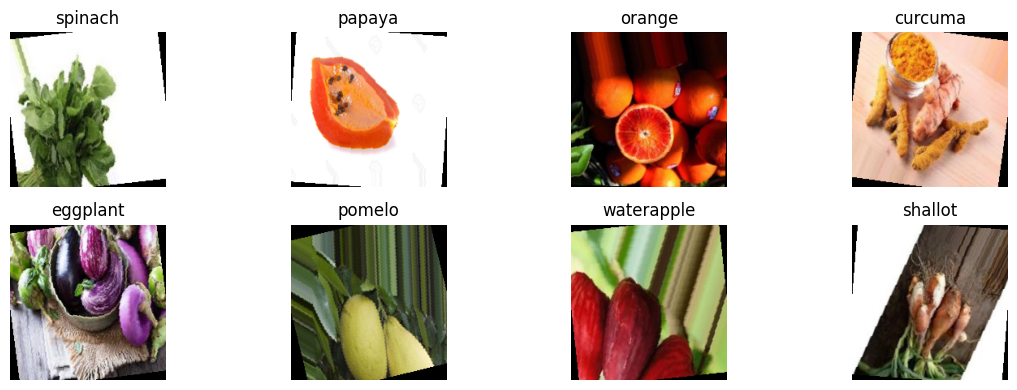

In [ ]:
inv_norm = transforms.Normalize(
    mean=[-m/s for m, s in zip(MEAN, STD)],
    std=[1/s for s in STD]
)

def show_batch(loader, n=8):
    xb, yb = next(iter(loader))
    imgs = torch.clamp(inv_norm(xb.clone()), 0, 1)
    n = min(n, xb.size(0))
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(2, math.ceil(n/2), i+1)
        plt.imshow(np.transpose(imgs[i].numpy(), (1,2,0)))
        plt.title(class_names[yb[i].item()])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_batch(train_loader, n=8)


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int, input_size: int = IMG_SIZE):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
        )
        with torch.no_grad():
            dummy_input = torch.zeros(1, 3, input_size, input_size)
            flattened_size = self.features(dummy_input).view(1, -1).size(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
class LitClassifier(pl.LightningModule):
    def __init__(self, model: nn.Module, num_classes: int, lr=1e-3, weight_decay=1e-4):
        super().__init__()
        self.save_hyperparameters(ignore=['model'])
        self.model = model
        self.lr = lr
        self.weight_decay = weight_decay

        self.acc  = MulticlassAccuracy(num_classes=num_classes)
        self.prec = MulticlassPrecision(num_classes=num_classes, average="macro")
        self.rec  = MulticlassRecall(num_classes=num_classes, average="macro")
        self.f1   = MulticlassF1Score(num_classes=num_classes, average="macro")

    def forward(self, x): return self.model(x)

    def _shared_step(self, batch, stage: str):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)
        self.acc.update(preds, y)
        self.prec.update(preds, y)
        self.rec.update(preds, y)
        self.f1.update(preds, y)
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, batch_size=x.size(0))
        return loss

    def training_step(self, batch, idx): return self._shared_step(batch, "train")
    def validation_step(self, batch, idx): return self._shared_step(batch, "val")
    def test_step(self, batch, idx): return self._shared_step(batch, "test")

    def _epoch_metrics(self, stage: str):
        self.log(f"{stage}_acc",  self.acc.compute(),  prog_bar=True)
        self.log(f"{stage}_precision", self.prec.compute(), prog_bar=False)
        self.log(f"{stage}_recall",    self.rec.compute(),  prog_bar=False)
        self.log(f"{stage}_f1",        self.f1.compute(),   prog_bar=True)
        self.acc.reset(); self.prec.reset(); self.rec.reset(); self.f1.reset()

    def on_train_epoch_end(self): self._epoch_metrics("train")
    def on_validation_epoch_end(self): self._epoch_metrics("val")
    def on_test_epoch_end(self): self._epoch_metrics("test")

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", patience=2, factor=0.5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}


In [ ]:
baseline = LitClassifier(SimpleCNN(num_classes).to(device), num_classes=num_classes, lr=1e-3, weight_decay=1e-4)

ckpt_cb = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="simplecnn-best")
es_cb   = EarlyStopping(monitor="val_loss", mode="min", patience=5)
lr_cb   = LearningRateMonitor(logging_interval='epoch')

trainer_baseline = pl.Trainer(
    max_epochs=15,
    accelerator="auto", devices=1,
    callbacks=[ckpt_cb, es_cb, lr_cb],
    log_every_n_steps=10, deterministic=True
)

trainer_baseline.fit(baseline, train_dataloaders=train_loader, val_dataloaders=val_loader)
best_simplecnn_path = ckpt_cb.best_model_path
best_simplecnn_path


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type                | Params | Mode 
------------------------------------------------------
0 | model | SimpleCNN           | 19.0 M | train
1 | acc   | MulticlassAccuracy  | 0      | train
2 | prec  | MulticlassPrecision | 0      | train
3 | rec   | MulticlassRecall    | 0      | train
4 | f1    | MulticlassF1Score   | 0      | train
------------------------------------------------------
19.0 M    Trainable params
0         Non-trainable params
19.0 M    Total params
75.902    Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


'/content/lightning_logs/version_2/checkpoints/simplecnn-best.ckpt'

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.7447844743728638     │
│          test_f1          │    0.7448768615722656     │
│         test_loss         │     0.776536762714386     │
│      test_precision       │    0.7550919055938721     │
│        test_recall        │    0.7447844743728638     │
└───────────────────────────┴───────────────────────────┘

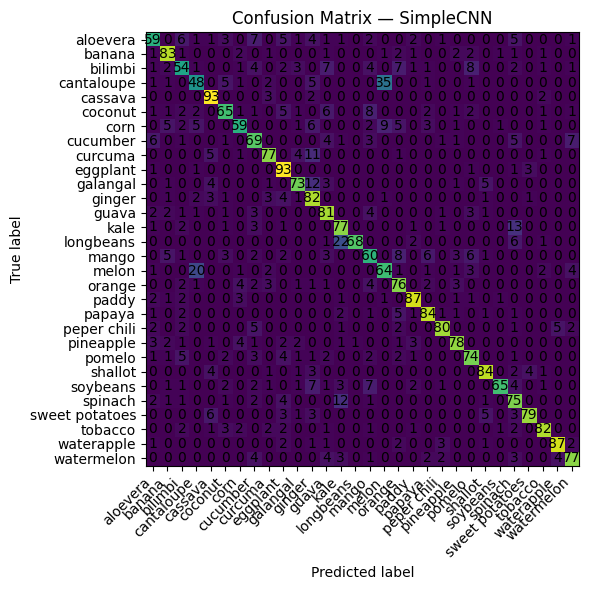

                precision    recall  f1-score   support

      aloevera       0.69      0.59      0.63       100
        banana       0.78      0.83      0.80       100
       bilimbi       0.61      0.54      0.57       100
    cantaloupe       0.59      0.48      0.53       100
       cassava       0.79      0.93      0.85       100
       coconut       0.74      0.65      0.69       100
          corn       0.75      0.59      0.66       100
      cucumber       0.64      0.70      0.67        99
       curcuma       0.80      0.77      0.79       100
      eggplant       0.72      0.93      0.81       100
      galangal       0.80      0.73      0.76       100
        ginger       0.59      0.82      0.69       100
         guava       0.69      0.81      0.75       100
          kale       0.62      0.77      0.69       100
     longbeans       0.99      0.68      0.80       100
         mango       0.60      0.60      0.60       100
         melon       0.58      0.64      0.61  

In [ ]:
if best_simplecnn_path:
    baseline = LitClassifier.load_from_checkpoint(best_simplecnn_path, model=SimpleCNN(num_classes).to(device),
                                             num_classes=num_classes, lr=1e-3, weight_decay=1e-4)

test_metrics_baseline = trainer_baseline.test(baseline, dataloaders=test_loader)

cm_metric = MulticlassConfusionMatrix(num_classes=num_classes)
baseline.eval().to(device)
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = baseline(xb.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_true.append(yb)
        cm_metric.update(preds, yb)
cm = cm_metric.compute().numpy()

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix — SimpleCNN")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout(); plt.show()

y_true = torch.cat(all_true).numpy()
y_pred = torch.cat(all_preds).numpy()
print(classification_report(y_true, y_pred, target_names=class_names))

In [ ]:
class LitResNet18(pl.LightningModule):
    def __init__(self, num_classes: int, lr=1e-3, weight_decay=1e-4, freeze_epochs=2):
        super().__init__()
        self.save_hyperparameters()
        self.model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_feats = self.model.fc.in_features
        self.model.fc = nn.Linear(in_feats, num_classes)

        self.acc  = MulticlassAccuracy(num_classes=num_classes)
        self.prec = MulticlassPrecision(num_classes=num_classes, average="macro")
        self.rec  = MulticlassRecall(num_classes=num_classes, average="macro")
        self.f1   = MulticlassF1Score(num_classes=num_classes, average="macro")

        self.freeze_epochs = freeze_epochs
        self._set_backbone_trainable(False)

    def _set_backbone_trainable(self, trainable: bool):
        for name, p in self.model.named_parameters():
            if name.startswith("fc."):
                p.requires_grad = True
            else:
                p.requires_grad = trainable

    def on_train_epoch_start(self):
        if self.current_epoch == self.freeze_epochs:
            self._set_backbone_trainable(True)

    def forward(self, x): return self.model(x)

    def _shared(self, batch, stage):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        preds = logits.argmax(dim=1)
        self.acc.update(preds, y)
        self.prec.update(preds, y)
        self.rec.update(preds, y)
        self.f1.update(preds, y)
        self.log(f"{stage}_loss", loss, prog_bar=True, on_epoch=True, batch_size=x.size(0))
        return loss

    def training_step(self, b, i): return self._shared(b, "train")
    def validation_step(self, b, i): return self._shared(b, "val")
    def test_step(self, b, i): return self._shared(b, "test")

    def _epoch_metrics(self, stage):
        self.log(f"{stage}_acc",  self.acc.compute(),  prog_bar=True)
        self.log(f"{stage}_precision", self.prec.compute(), prog_bar=False)
        self.log(f"{stage}_recall",    self.rec.compute(),  prog_bar=False)
        self.log(f"{stage}_f1",        self.f1.compute(),   prog_bar=True)
        self.acc.reset(); self.prec.reset(); self.rec.reset(); self.f1.reset()

    def on_train_epoch_end(self): self._epoch_metrics("train")
    def on_validation_epoch_end(self): self._epoch_metrics("val")
    def on_test_epoch_end(self): self._epoch_metrics("test")

    def configure_optimizers(self):
        opt = torch.optim.Adam(self.parameters(), lr=self.hparams.lr, weight_decay=self.hparams.weight_decay)
        sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", patience=2, factor=0.5)
        return {"optimizer": opt, "lr_scheduler": {"scheduler": sch, "monitor": "val_loss"}}


In [ ]:
resnet = LitResNet18(num_classes=num_classes, lr=1e-3, weight_decay=1e-4, freeze_epochs=2)

ckpt_cb_r = ModelCheckpoint(monitor="val_acc", mode="max", save_top_k=1, filename="resnet18-best")
es_cb_r   = EarlyStopping(monitor="val_loss", mode="min", patience=5)
lr_cb_r   = LearningRateMonitor(logging_interval='epoch')

trainer_resnet = pl.Trainer(
    max_epochs=12,
    accelerator="auto", devices=1,
    callbacks=[ckpt_cb_r, es_cb_r, lr_cb_r],
    log_every_n_steps=10, deterministic=True
)

trainer_resnet.fit(resnet, train_dataloaders=train_loader, val_dataloaders=val_loader)
best_resnet_path = ckpt_cb_r.best_model_path
best_resnet_path


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type                | Params | Mode 
------------------------------------------------------
0 | model | ResNet              | 11.2 M | train
1 | acc   | MulticlassAccuracy  | 0      | train
2 | prec  | MulticlassPrecision | 0      | train
3 | rec   | MulticlassRecall    | 0      | train
4 | f1    | MulticlassF1Score   | 0      | train
------------------------------------------------------
15.4 K    Trainable params
11.2 M    Non-trainable params
11.2 M    Total params
44.768    Total estimated model params size (MB)
72        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=12` reached.


'/content/lightning_logs/version_1/checkpoints/resnet18-best.ckpt'

In [ ]:
!cp /content/lightning_logs/version_1/checkpoints/resnet18-best.ckpt "/content/drive/MyDrive/"

cp: cannot create regular file '/content/drive/MyDrive/': No such file or directory


In [ ]:
best_resnet_path

'/content/lightning_logs/version_1/checkpoints/resnet18-best.ckpt'

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9816633462905884     │
│          test_f1          │    0.9815740585327148     │
│         test_loss         │    0.05388402193784714    │
│      test_precision       │     0.982273519039154     │
│        test_recall        │    0.9816633462905884     │
└───────────────────────────┴───────────────────────────┘

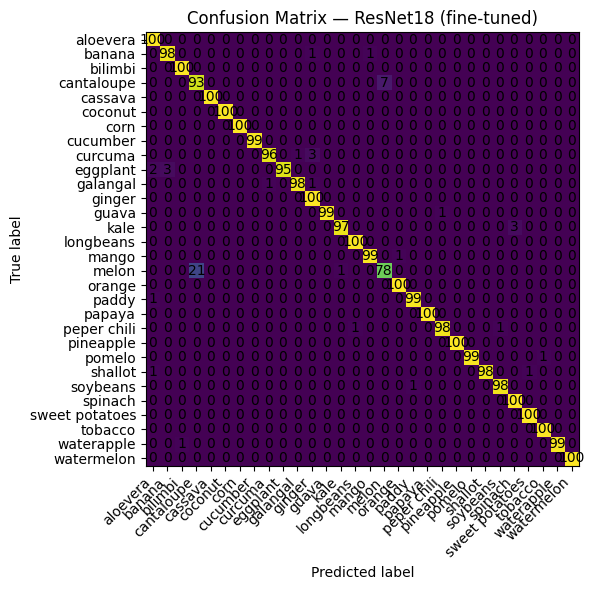

                precision    recall  f1-score   support

      aloevera       0.96      1.00      0.98       100
        banana       0.97      0.98      0.98       100
       bilimbi       0.99      1.00      1.00       100
    cantaloupe       0.82      0.93      0.87       100
       cassava       1.00      1.00      1.00       100
       coconut       1.00      1.00      1.00       100
          corn       1.00      1.00      1.00       100
      cucumber       1.00      1.00      1.00        99
       curcuma       0.99      0.96      0.97       100
      eggplant       1.00      0.95      0.97       100
      galangal       0.99      0.98      0.98       100
        ginger       0.95      1.00      0.98       100
         guava       1.00      0.99      0.99       100
          kale       0.99      0.97      0.98       100
     longbeans       0.99      1.00      1.00       100
         mango       0.99      0.99      0.99       100
         melon       0.92      0.78      0.84  

In [ ]:
if best_resnet_path:
    resnet = LitResNet18.load_from_checkpoint(best_resnet_path,
                                         num_classes=num_classes, lr=1e-3, weight_decay=1e-4, freeze_epochs=2)

test_metrics_resnet = trainer_resnet.test(resnet, dataloaders=test_loader)

cm_metric_r = MulticlassConfusionMatrix(num_classes=num_classes)
resnet.eval().to(device)
all_preds_r, all_true_r = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        logits = resnet(xb.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds_r.append(preds); all_true_r.append(yb)
        cm_metric_r.update(preds, yb)
cm_r = cm_metric_r.compute().numpy()

plt.figure(figsize=(8,6))
plt.imshow(cm_r, interpolation='nearest')
plt.title("Confusion Matrix — ResNet18 (fine-tuned)")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, int(cm_r[i, j]), ha="center", va="center")
plt.ylabel("True label"); plt.xlabel("Predicted label")
plt.tight_layout(); plt.show()

y_true_r = torch.cat(all_true_r).numpy()
y_pred_r = torch.cat(all_preds_r).numpy()
print(classification_report(y_true_r, y_pred_r, target_names=class_names))

SimpleCNN metrics: {'test_loss': 0.776536762714386, 'test_acc': 0.7447844743728638, 'test_precision': 0.7550919055938721, 'test_recall': 0.7447844743728638, 'test_f1': 0.7448768615722656}
ResNet18  metrics: {'test_loss': 0.05388402193784714, 'test_acc': 0.9816633462905884, 'test_precision': 0.982273519039154, 'test_recall': 0.9816633462905884, 'test_f1': 0.9815740585327148}


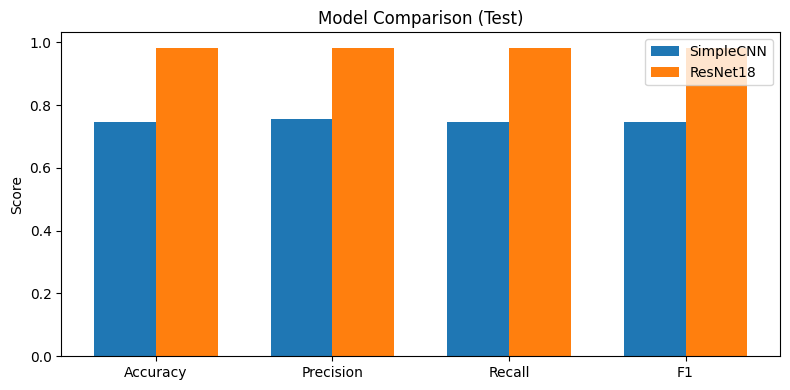

In [ ]:
def extract_last_metrics(trainer):
    out = {}
    for k, v in trainer.callback_metrics.items():
        try:
            out[k] = float(v.cpu().item())
        except Exception:
            pass
    return out

simplecnn_metrics = extract_last_metrics(trainer_baseline)
resnet_metrics    = extract_last_metrics(trainer_resnet)

print("SimpleCNN metrics:", simplecnn_metrics)
print("ResNet18  metrics:", resnet_metrics)

keys = ["test_acc", "test_precision", "test_recall", "test_f1"]
labels = ["Accuracy", "Precision", "Recall", "F1"]
vals_simple = [simplecnn_metrics.get(k, np.nan) for k in keys]
vals_resnet = [resnet_metrics.get(k, np.nan) for k in keys]

x = np.arange(len(keys)); w = 0.35
plt.figure(figsize=(8,4))
plt.bar(x - w/2, vals_simple, width=w, label="SimpleCNN")
plt.bar(x + w/2, vals_resnet,  width=w, label="ResNet18")
plt.xticks(x, labels); plt.ylabel("Score"); plt.title("Model Comparison (Test)")
plt.legend(); plt.tight_layout(); plt.show()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


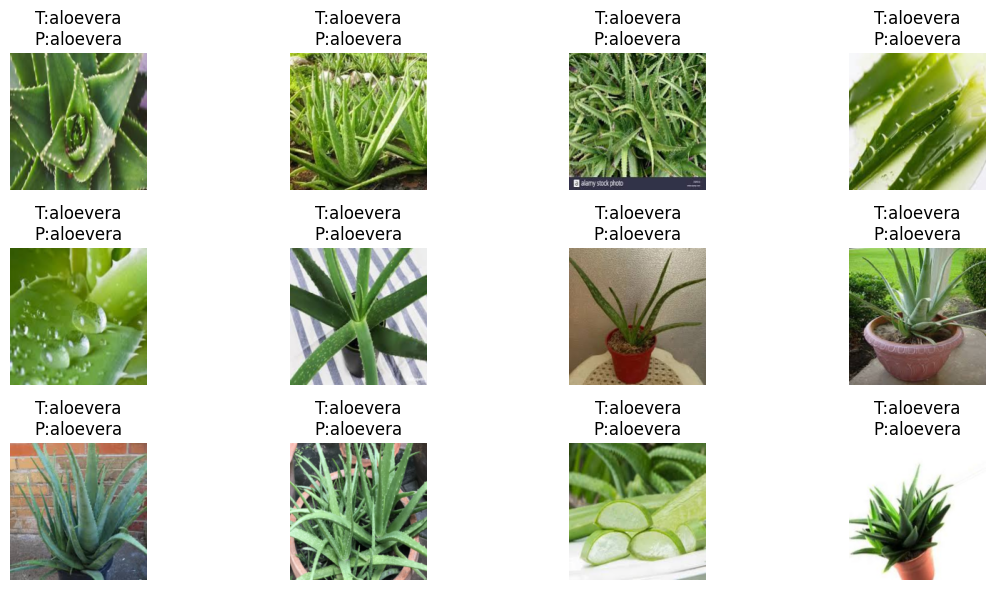

In [ ]:
xb, yb = next(iter(test_loader))
resnet.eval().to(device)
with torch.no_grad():
    preds = resnet(xb.to(device)).argmax(dim=1).cpu()

inv_xb = torch.clamp(inv_norm(xb.clone()), 0, 1)
n = min(12, xb.size(0))
plt.figure(figsize=(12, 6))
for i in range(n):
    plt.subplot(3, math.ceil(n/3), i+1)
    plt.imshow(np.transpose(inv_xb[i].numpy(), (1,2,0)))
    t = class_names[yb[i].item()]; p = class_names[preds[i].item()]
    plt.title(f"T:{t}\nP:{p}"); plt.axis("off")
plt.tight_layout(); plt.show()
